# Numerical Model of a PCM-Enhanced Brick
## Transient 1D Heat Conduction — Aligned with Experimental Sensors

This notebook simulates transient one-dimensional heat conduction through a brick.

Two cases are compared:
1. **Standard brick** (constant thermal properties)
2. **PCM-enhanced brick** (paraffin microcapsules modeled via an **effective heat capacity** formulation)

Outputs are designed to match experimental measurements:
- Temperature vs time at **bottom**, **mid-height**, and **top** sensor positions
- A simple, publishable metric: **thermal delay** Δt to reach a chosen threshold temperature at the top
- Estimated **heat flux** at the heated boundary vs time


## Physical Model

The governing equation for 1D transient heat conduction is:

\[
\rho c_p \frac{\partial T}{\partial t} = k \frac{\partial^2 T}{\partial x^2}
\]

To represent **phase change** (paraffin microcapsules), we do **not** force an artificial conductivity law.
Instead, we capture latent heat using an **effective heat capacity** within a small melting interval:

\[
c_{p,\mathrm{eff}}(T) = c_p + \frac{L}{\Delta T} \quad \text{(only inside the melting interval)}
\]

Within that interval, the material absorbs extra energy (latent heat), so temperature rises more slowly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Geometry and discretization
L = 0.10          # m
Nx = 50           # number of spatial nodes
dx = L / (Nx - 1)
x = np.linspace(0, L, Nx)

print(f'dx = {dx:.6f} m')

dx = 0.002041 m


In [3]:
# Time parameters
dt = 0.05         # s
Nt = 2000         # number of time steps
time = np.arange(Nt) * dt

print(f'Total simulated time = {time[-1]:.2f} s')

Total simulated time = 99.95 s


In [4]:
# Material properties (brick-like)
rho = 1800.0      # kg/m^3
k = 0.5           # W/(m·K)
cp = 800.0        # J/(kg·K)

# PCM (paraffin microcapsules) parameters (approximate)
L_latent = 150000.0   # J/kg (latent heat)
T_melt = 330.0        # K (melting temperature)
delta_T = 5.0         # K (width of the melting interval)

# Stability check for explicit scheme (worst case: smallest cp -> largest alpha)
alpha_const = k / (rho * cp)
r = alpha_const * dt / dx**2
print(f'alpha_const = {alpha_const:.3e} m^2/s')
print(f'r = alpha*dt/dx^2 = {r:.4f}  (should be <= 0.5 for stability)')

alpha_const = 3.472e-07 m^2/s
r = alpha*dt/dx^2 = 0.0042  (should be <= 0.5 for stability)


In [5]:
def cp_effective(T, cp_base=cp, L=L_latent, Tm=T_melt, dT=delta_T):
    """Effective heat capacity model for PCM using a smeared latent heat approach.

    Adds L/dT to cp inside the melting interval [Tm - dT/2, Tm + dT/2].
    """
    T = np.asarray(T)
    cp_eff = np.full_like(T, cp_base, dtype=float)
    mask = (T > (Tm - dT/2)) & (T < (Tm + dT/2))
    cp_eff[mask] = cp_base + (L / dT)
    return cp_eff

In [6]:
# Boundary conditions (Dirichlet)
T0 = 350.0   # K  (heated boundary at x=0)
Tf = 300.0   # K  (cold boundary at x=L)

# Initial condition: start at Tf everywhere, with hot boundary enforced
T_const = np.ones(Nx) * Tf
T_pcm = np.ones(Nx) * Tf

T_const[0] = T0
T_pcm[0] = T0

print(f'Boundary temperatures: T0={T0} K, Tf={Tf} K')

Boundary temperatures: T0=350.0 K, Tf=300.0 K


In [7]:
# Sensor-equivalent positions (match your experimental placement idea)
# We avoid the exact boundaries to represent sensors taped on the surface, not inside boundary nodes.
idx_bottom = 1
idx_mid = Nx // 2
idx_top = Nx - 2

print('Sensor indices:', idx_bottom, idx_mid, idx_top)
print('Sensor x positions (m):', x[idx_bottom], x[idx_mid], x[idx_top])

Sensor indices: 1 25 48
Sensor x positions (m): 0.0020408163265306124 0.05102040816326531 0.0979591836734694


In [8]:
# Storage arrays for sensor temperatures
bottom_const, mid_const, top_const = [], [], []
bottom_pcm, mid_pcm, top_pcm = [], [], []

# Storage arrays for heat flux at heated boundary (x=0)
flux_const, flux_pcm = [], []

## Numerical Scheme (Explicit Finite Differences)

For interior nodes:

$$
T_i^{n+1} = T_i^n + \alpha \frac{\Delta t}{\Delta x^2}\left(T_{i+1}^n - 2T_i^n + T_{i-1}^n\right)
$$

Where:
\(α = k/(\rho c_p)\) for the constant material, and
\(α(T) = k/(\rho c_{p,eff}(T))\) for the PCM-enhanced case.


In [ ]:
# Time integration
for n in range(Nt):
    Tn_const = T_const.copy()
    Tn_pcm = T_pcm.copy()

    # Update interior nodes
    for i in range(1, Nx - 1):
        # Constant material
        alpha_c = k / (rho * cp)
        T_const[i] = Tn_const[i] + alpha_c * dt / dx**2 * (
            Tn_const[i+1] - 2*Tn_const[i] + Tn_const[i-1]
        )

        # PCM-enhanced material
        cp_eff_i = cp_effective(Tn_pcm[i])  # scalar
        alpha_p = k / (rho * cp_eff_i)
        T_pcm[i] = Tn_pcm[i] + alpha_p * dt / dx**2 * (
            Tn_pcm[i+1] - 2*Tn_pcm[i] + Tn_pcm[i-1]
        )

    # Enforce boundary conditions
    T_const[0] = T0
    T_const[-1] = Tf
    T_pcm[0] = T0
    T_pcm[-1] = Tf

    # Save sensor temperatures
    bottom_const.append(T_const[idx_bottom])
    mid_const.append(T_const[idx_mid])
    top_const.append(T_const[idx_top])

    bottom_pcm.append(T_pcm[idx_bottom])
    mid_pcm.append(T_pcm[idx_mid])
    top_pcm.append(T_pcm[idx_top])

    # Estimate heat flux at heated boundary using a one-sided gradient
    # q = -k dT/dx ≈ -k (T1 - T0) / dx
    flux_const.append(-k * (T_const[1] - T_const[0]) / dx)
    flux_pcm.append(-k * (T_pcm[1] - T_pcm[0]) / dx)

bottom_const = np.array(bottom_const)
mid_const = np.array(mid_const)
top_const = np.array(top_const)

bottom_pcm = np.array(bottom_pcm)
mid_pcm = np.array(mid_pcm)
top_pcm = np.array(top_pcm)

flux_const = np.array(flux_const)
flux_pcm = np.array(flux_pcm)


Simulation complete.


## Temperature vs Time at Sensor Positions

These curves correspond directly to what you will record experimentally.
The PCM case should show a **delay** (slower temperature rise) near the melting interval.

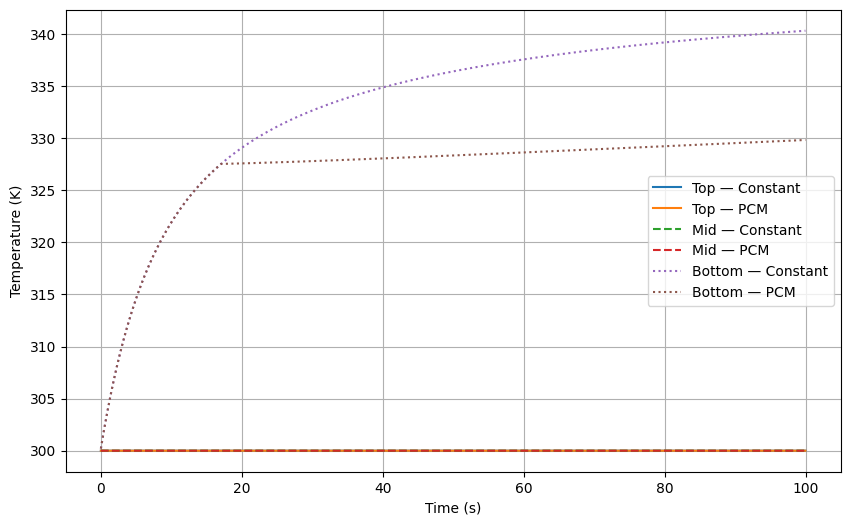

In [10]:
plt.figure(figsize=(10,6))

plt.plot(time, top_const, label='Top — Constant')
plt.plot(time, top_pcm, label='Top — PCM')

plt.plot(time, mid_const, '--', label='Mid — Constant')
plt.plot(time, mid_pcm, '--', label='Mid — PCM')

plt.plot(time, bottom_const, ':', label='Bottom — Constant')
plt.plot(time, bottom_pcm, ':', label='Bottom — PCM')

plt.xlabel('Time (s)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.grid(True)
plt.show()

## Publishable Metric: Thermal Delay Δt (Threshold Crossing)

A practical way to validate the model is to define a **threshold temperature** at the *top sensor*.
We compute the first time the top reaches that threshold in both cases.

\[
\Delta t = t_{PCM} - t_{const}
\]

This is easy to measure experimentally and easy to report in a paper.

Threshold = 320.0 K
Constant reaches threshold at t = nan s
PCM reaches threshold at      t = nan s
Thermal delay Δt =            nan s


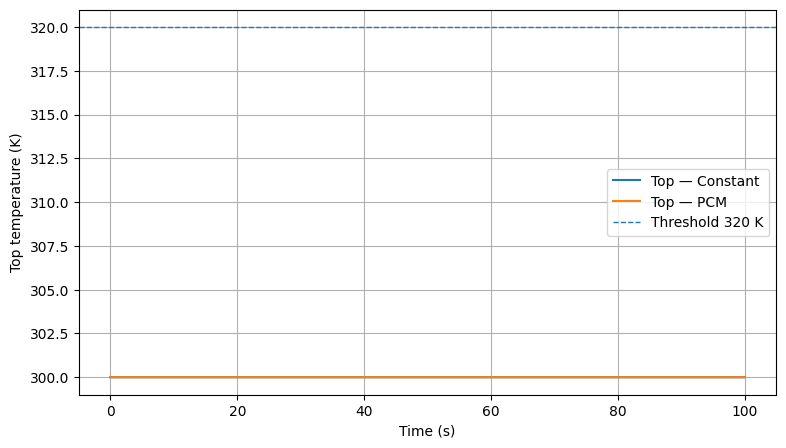

In [11]:
def first_crossing_time(t, y, threshold):
    """Return the first time t when y >= threshold. Returns np.nan if never crossed."""
    idx = np.where(y >= threshold)[0]
    if idx.size == 0:
        return np.nan
    return t[idx[0]]

threshold = 320.0  # K (choose what you will also use experimentally)

t_const = first_crossing_time(time, top_const, threshold)
t_pcm = first_crossing_time(time, top_pcm, threshold)
delta_t = t_pcm - t_const

print(f'Threshold = {threshold:.1f} K')
print(f'Constant reaches threshold at t = {t_const:.2f} s')
print(f'PCM reaches threshold at      t = {t_pcm:.2f} s')
print(f'Thermal delay Δt =            {delta_t:.2f} s')

# Plot with threshold line
plt.figure(figsize=(9,5))
plt.plot(time, top_const, label='Top — Constant')
plt.plot(time, top_pcm, label='Top — PCM')
plt.axhline(threshold, linestyle='--', linewidth=1, label=f'Threshold {threshold:.0f} K')
plt.xlabel('Time (s)')
plt.ylabel('Top temperature (K)')
plt.legend()
plt.grid(True)
plt.show()

## Estimated Heat Flux at the Heated Boundary

We estimate the heat flux at the heated boundary using a one-sided gradient:

$$
q(t) = -k \frac{T_1(t) - T_0}{\Delta x}
$$

This gives a simple quantitative comparison of how the PCM affects the incoming heat flow over time.

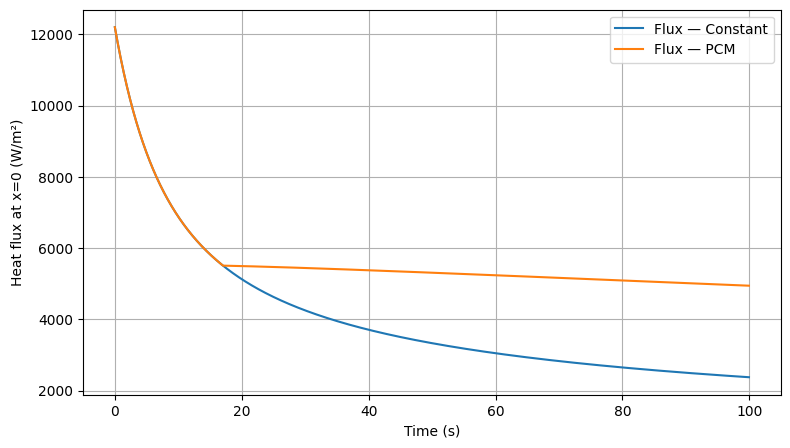

In [12]:
plt.figure(figsize=(9,5))
plt.plot(time, flux_const, label='Flux — Constant')
plt.plot(time, flux_pcm, label='Flux — PCM')
plt.xlabel('Time (s)')
plt.ylabel('Heat flux at x=0 (W/m²)')
plt.legend()
plt.grid(True)
plt.show()

## Next Phase (when you have experimental data)

Once you record the three sensor signals for both bricks, you can:
- Compute Δt experimentally using the **same threshold**
- Compare simulated vs experimental Δt
- Fit/adjust uncertain parameters (e.g., effective PCM fraction, \(L\), \(\Delta T\), boundary conditions)
- Report error metrics (e.g., absolute error in Δt, RMSE of temperature curves)
